# Groundwater recharge — raw vs STAC folder vs cloud

Checks that the two groundwater recharge rasters (`RF_recharge_01`, `RF_RK_recharge_01`) are the same in the three places they live:

1. **Raw**: `P:\...\Data_Vivian\<name>.tif` (original GeoTIFFs)
2. **STAC folder**: `P:\...\Data_Vivian\stac\groundwater_recharge\cog\<name>.tif` (COGs produced by `notebooks/20_groundwater_recharge.ipynb`)
3. **Cloud**: the COGs found through the public STAC catalog (`gca-stac-7`, collection `groundwater_recharge`)

The rasters are plotted side by side and compared pixel by pixel. The raw files use different nodata values (`-9999` and `-3.4e38`), the COGs use `-9999`, so the comparison is done on valid pixels only.

Environment: `environment_exploration.yml` (Miniforge).

In [1]:
import time
from pathlib import Path
from posixpath import join as urljoin

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pystac_client
import rasterio

## 1) Locations

In [2]:
data_vivian = Path(r"P:\11209117-041-ipdc-egypt-swi\data\IntDeltaPlatform_QGA\Data_Vivian")
names = ["RF_recharge_01", "RF_RK_recharge_01"]
raw_paths = {n: data_vivian / f"{n}.tif" for n in names}
stac_folder_paths = {n: data_vivian / "stac" / "groundwater_recharge" / "cog" / f"{n}.tif" for n in names}

gcs_protocol = "https://storage.googleapis.com"
catalog_url = urljoin(gcs_protocol, "gca-data-public", "gca", "gca-stac-7", "catalog.json")
collection_id = "groundwater_recharge"

for p in (*raw_paths.values(), *stac_folder_paths.values()):
    print(p.is_file(), p)

True P:\11209117-041-ipdc-egypt-swi\data\IntDeltaPlatform_QGA\Data_Vivian\RF_recharge_01.tif
True P:\11209117-041-ipdc-egypt-swi\data\IntDeltaPlatform_QGA\Data_Vivian\RF_RK_recharge_01.tif
True P:\11209117-041-ipdc-egypt-swi\data\IntDeltaPlatform_QGA\Data_Vivian\stac\groundwater_recharge\cog\RF_recharge_01.tif
True P:\11209117-041-ipdc-egypt-swi\data\IntDeltaPlatform_QGA\Data_Vivian\stac\groundwater_recharge\cog\RF_RK_recharge_01.tif


## 2) Find the data through the STAC catalog

In [3]:
# public objects are cached for 1 h: a query string forces a fresh copy of catalog.json
catalog = pystac_client.Client.open(f"{catalog_url}?nocache={time.time()}")
# get_collection() can return another collection on a static catalog: match the id explicitly
collection = next((c for c in catalog.get_children() if c.id == collection_id), None)
if collection is None:
    raise LookupError(f"Collection {collection_id} not found in {catalog_url}")

items = {i.id: i for i in collection.get_items()}
print("Collection:", collection.id, "|", collection.title)
print("Items:", list(items))

cloud_hrefs = {}
for n in names:
    item = items[n]
    cloud_hrefs[n] = item.assets["data"].href
    assert collection_id in cloud_hrefs[n], f"Unexpected href: {cloud_hrefs[n]}"
    print(f"{n}: model {item.properties.get('recharge:model')} | {cloud_hrefs[n]}")
    print("   raster bands:", item.assets["data"].extra_fields.get("raster:bands"))

c:\Users\fuentesm\AppData\Local\miniforge3\envs\gca-exploration\Lib\site-packages\pystac_client\client.py:191: NoConformsTo: Server does not advertise any conformance classes.
  warnings.warn(NoConformsTo())


Collection: groundwater_recharge | Groundwater Recharge in Africa from Ground Based Measurements
Items: ['RF_recharge_01', 'RF_RK_recharge_01']
RF_recharge_01: model RF | https://storage.googleapis.com/gca-data-public/gca/groundwater_recharge/RF_recharge_01.tif
   raster bands: [{'nodata': -9999.0, 'data_type': 'float32', 'spatial_resolution': 0.1, 'unit': 'mm/year'}]
RF_RK_recharge_01: model RF_RK | https://storage.googleapis.com/gca-data-public/gca/groundwater_recharge/RF_RK_recharge_01.tif
   raster bands: [{'nodata': -9999.0, 'data_type': 'float32', 'spatial_resolution': 0.1, 'unit': 'mm/year'}]


c:\Users\fuentesm\AppData\Local\miniforge3\envs\gca-exploration\Lib\site-packages\pystac_client\collection_client.py:149: FallbackToPystac: Falling back to pystac. This might be slow.
  root._warn_about_fallback("ITEM_SEARCH")


## 3) Read the rasters

In [4]:
sources = {
    n: {"raw (P:)": str(raw_paths[n]), "stac folder (P:)": str(stac_folder_paths[n]), "cloud (catalog)": cloud_hrefs[n]}
    for n in names
}

arrays, profiles = {}, {}
for n, srcs in sources.items():
    for label, path in srcs.items():
        with rasterio.open(path) as src:
            data = src.read(1).astype("float64")
            # Valid = finite and not the file's own nodata (raw files use different nodata values)
            valid = np.isfinite(data)
            if src.nodata is not None:
                valid &= ~np.isclose(data, src.nodata)
            arrays[(n, label)] = np.where(valid, data, np.nan)
            profiles[(n, label)] = {
                "shape": src.shape,
                "dtype": src.dtypes[0],
                "nodata": src.nodata,
                "crs": src.crs.to_string(),
                "transform": tuple(round(v, 6) for v in src.transform)[:6],
                "tiled (COG)": src.is_tiled,
                "overviews": src.overviews(1),
                "compression": str(src.compression),
                "bounds": tuple(round(v, 3) for v in src.bounds),
                "valid pixels": int(valid.sum()),
            }

pd.DataFrame(profiles).T

shape    dtype  \
RF_recharge_01    raw (P:)          (721, 888)  float32   
                  stac folder (P:)  (721, 888)  float32   
                  cloud (catalog)   (721, 888)  float32   
RF_RK_recharge_01 raw (P:)          (721, 888)  float32   
                  stac folder (P:)  (721, 888)  float32   
                  cloud (catalog)   (721, 888)  float32   

                                                                       nodata  \
RF_recharge_01    raw (P:)                                            -9999.0   
                  stac folder (P:)                                    -9999.0   
                  cloud (catalog)                                     -9999.0   
RF_RK_recharge_01 raw (P:)         -339999995214436424907732413799364296704.0   
                  stac folder (P:)                                    -9999.0   
                  cloud (catalog)                                     -9999.0   

                                          crs  \
RF_recharge_01    raw (P:)          EPSG:4326   
                  stac folder (P:)  EPSG:4326   
                  cloud (catalog)   EPSG:4326   
RF_RK_recharge_01 raw (P:)          EPSG:4326   
                  stac folder (P:)  EPSG:4326   
                  cloud (catalog)   EPSG:4326   

                                                                           transform  \
RF_recharge_01    raw (P:)          (0.100056, 0.0, -25.375, 0.0, -0.100069, 37.325)   
                  stac folder (P:)  (0.100056, 0.0, -25.375, 0.0, -0.100069, 37.325)   
                  cloud (catalog)   (0.100056, 0.0, -25.375, 0.0, -0.100069, 37.325)   
RF_RK_recharge_01 raw (P:)          (0.100056, 0.0, -25.375, 0.0, -0.100069, 37.325)   
                  stac folder (P:)  (0.100056, 0.0, -25.375, 0.0, -0.100069, 37.325)   
                  cloud (catalog)   (0.100056, 0.0, -25.375, 0.0, -0.100069, 37.325)   

                                   tiled (COG) overviews          compression  \
RF_recharge_01    raw (P:)               False        []                 None   
                  stac folder (P:)        True       [2]  Compression.deflate   
                  cloud (catalog)         True       [2]  Compression.deflate   
RF_RK_recharge_01 raw (P:)               False        []      Compression.lzw   
                  stac folder (P:)        True       [2]  Compression.deflate   
                  cloud (catalog)         True       [2]  Compression.deflate   

                                                                bounds  \
RF_recharge_01    raw (P:)          (-25.375, -34.825, 63.475, 37.325)   
                  stac folder (P:)  (-25.375, -34.825, 63.475, 37.325)   
                  cloud (catalog)   (-25.375, -34.825, 63.475, 37.325)   
RF_RK_recharge_01 raw (P:)          (-25.375, -34.825, 63.475, 37.325)   
                  stac folder (P:)  (-25.375, -34.825, 63.475, 37.325)   
                  cloud (catalog)   (-25.375, -34.825, 63.475, 37.325)   

                                   valid pixels  
RF_recharge_01    raw (P:)               252509  
                  stac folder (P:)       252509  
                  cloud (catalog)        252509  
RF_RK_recharge_01 raw (P:)               252509  
                  stac folder (P:)       252509  
                  cloud (catalog)        252509

## 4) Plot

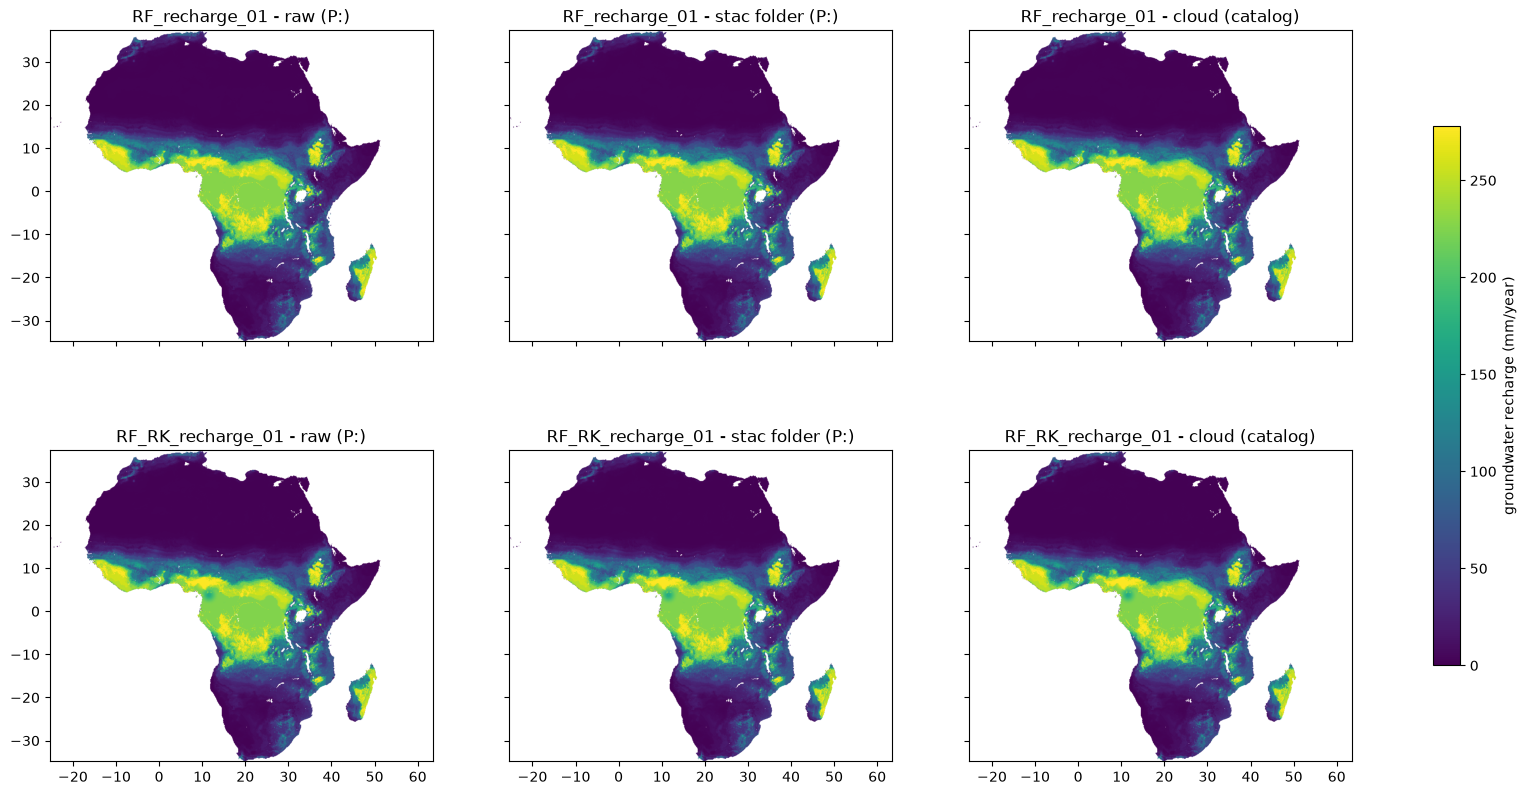

In [5]:
# Same colour scale for all panels so they can be compared by eye
vmax = float(np.nanpercentile(np.concatenate([a[~np.isnan(a)] for a in arrays.values()]), 99))
labels = list(sources[names[0]])

fig, axes = plt.subplots(len(names), len(labels), figsize=(7 * len(labels), 5 * len(names)), sharex=True, sharey=True)
for r, n in enumerate(names):
    for c, label in enumerate(labels):
        b = profiles[(n, label)]["bounds"]
        im = axes[r, c].imshow(arrays[(n, label)], cmap="viridis", vmin=0, vmax=vmax, extent=(b[0], b[2], b[1], b[3]))
        axes[r, c].set_title(f"{n} - {label}")
fig.colorbar(im, ax=axes, label="groundwater recharge (mm/year)", shrink=0.7)
plt.show()

## 5) Compare

In [6]:
results = []
ref = labels[0]
for n in names:
    a = arrays[(n, ref)]
    for other in labels[1:]:
        b = arrays[(n, other)]
        same_shape = a.shape == b.shape
        same_mask = same_shape and np.array_equal(np.isnan(a), np.isnan(b))
        n_diff = int((a[~np.isnan(a)] != b[~np.isnan(a)]).sum()) if same_mask else None
        results.append({
            "item": n,
            "comparison": f"{ref} vs {other}",
            "same shape": same_shape,
            "same CRS/transform": (profiles[(n, ref)]["crs"], profiles[(n, ref)]["transform"]) == (profiles[(n, other)]["crs"], profiles[(n, other)]["transform"]),
            "same valid mask": same_mask,
            "different valid pixels": n_diff,
            "identical": bool(same_mask and n_diff == 0),
        })
display(pd.DataFrame(results))

if all(r["identical"] for r in results):
    print("OK: raw, stac folder and cloud contain exactly the same data.")
else:
    print("MISMATCH: see the table above.")

# The two models are expected to differ: show how much
diff = arrays[(names[1], ref)] - arrays[(names[0], ref)]
print(f"{names[1]} minus {names[0]} (mm/year): mean {np.nanmean(diff):.2f}, min {np.nanmin(diff):.2f}, max {np.nanmax(diff):.2f}")

,item,comparison,same shape,same CRS/transform,same valid mask,different valid pixels,identical
0,RF_recharge_01,raw (P:) vs stac folder (P:),True,True,True,0,True
1,RF_recharge_01,raw (P:) vs cloud (catalog),True,True,True,0,True
2,RF_RK_recharge_01,raw (P:) vs stac folder (P:),True,True,True,0,True
3,RF_RK_recharge_01,raw (P:) vs cloud (catalog),True,True,True,0,True


OK: raw, stac folder and cloud contain exactly the same data.
RF_RK_recharge_01 minus RF_recharge_01 (mm/year): mean -0.52, min -78.36, max 128.66


## 6) Call the WMS service

Requests the two layers published in GeoServer (step 8 of `scripts/20_groundwater_recharge.ipynb`) through the `visual` asset of the STAC items, to check the service shows the same data. Needs access to the Deltares network. Colours come from the GeoServer style, so they will differ from the plots above.

WMS asset: https://international-delta-platform.avi.directory.intra/geoserver/wms/groundwater_recharge | layer: groundwater_recharge:RF_recharge_01
WMS asset: https://international-delta-platform.avi.directory.intra/geoserver/wms/groundwater_recharge | layer: groundwater_recharge:RF_RK_recharge_01


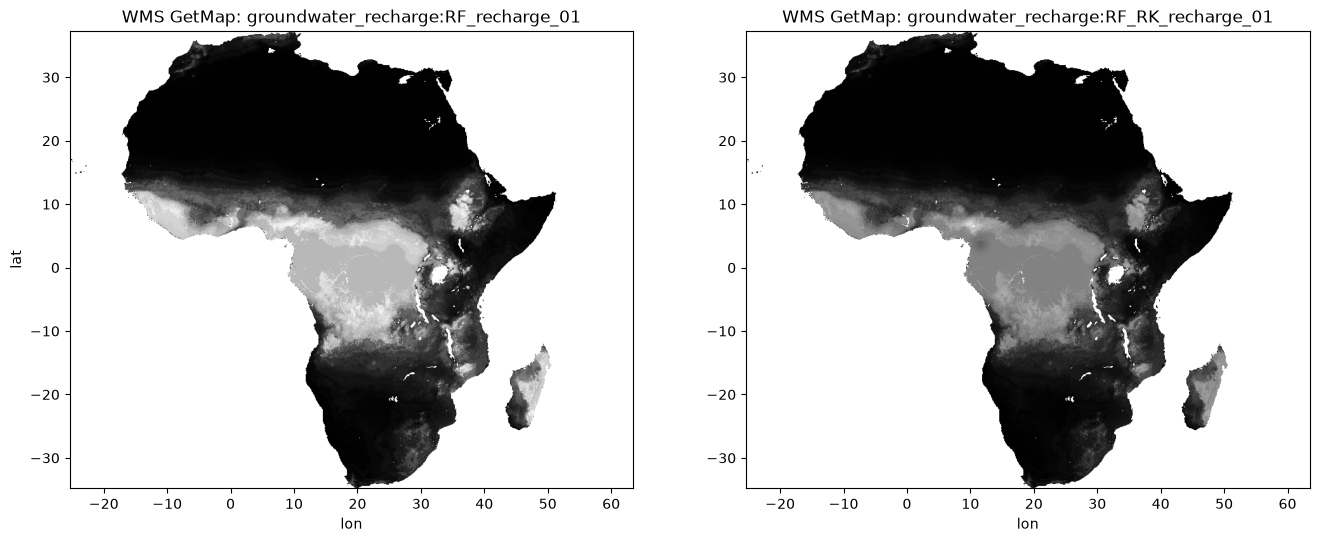

In [7]:
import io
import urllib3
import requests
import matplotlib.image as mpimg

urllib3.disable_warnings()  # the internal GeoServer uses a self-signed certificate

fig, axes = plt.subplots(1, len(names), figsize=(8 * len(names), 6))
for ax, n in zip(axes, names):
    # WMS endpoint taken from the STAC item's "visual" asset (added by scripts/20_groundwater_recharge.ipynb)
    wms_url = items[n].assets["visual"].href
    layer = f"{collection_id}:{n}"  # workspace:layer as published in step 8
    print("WMS asset:", wms_url, "| layer:", layer)

    bbox = items[n].bbox
    params = dict(
        SERVICE="WMS", VERSION="1.1.1", REQUEST="GetMap", LAYERS=layer, STYLES="",
        SRS="EPSG:4326", BBOX=",".join(str(v) for v in bbox), WIDTH=888, HEIGHT=721,
        FORMAT="image/png", TRANSPARENT="true",
    )
    resp = requests.get(wms_url, params=params, verify=False, timeout=60)
    resp.raise_for_status()
    if not resp.headers.get("Content-Type", "").startswith("image"):
        raise RuntimeError(resp.text[:500])  # GeoServer returns XML on errors

    ax.imshow(mpimg.imread(io.BytesIO(resp.content), format="png"), extent=(bbox[0], bbox[2], bbox[1], bbox[3]))
    ax.set_title(f"WMS GetMap: {layer}")
    ax.set_xlabel("lon")
axes[0].set_ylabel("lat")
plt.show()